In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import TensorDataset, DataLoader, random_split
from models import CondSM
from tqdm import tqdm
import math
from pathlib import Path
import torch.distributions

import os, random

def set_seed(seed: int, deterministic: bool = False):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        # More reproducible, sometimes slower
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        # Faster, may vary slightly run-to-run
        torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
dataset_num = 0
dist_type = 'uni_1e7'
data_folder = 'uni_1e7'
data_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/') / data_folder
num_batches = 400
batch_size = 1024
train_size = 0.8
val_size = 0.1
test_size = 0.1
output_idx = 0

In [14]:
voltages = []
currents = []
uncerts = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
        uncerts.append(batch['sem'][:, output_idx])
    else:
        currents.append(batch['currents'])
        uncerts.append(batch['sem'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
ys = np.concatenate(currents, axis=0)
sems = np.concatenate(uncerts, axis=0)

V = torch.from_numpy(vs).float()
y = torch.from_numpy(ys).unsqueeze(-1).float()
Sem = torch.from_numpy(sems).unsqueeze(-1).float()

print(Sem.min(), Sem.median(), Sem.max())

print(V.shape)
print(y.shape)
print(Sem.shape)

dataset = TensorDataset(V, y, Sem)

generator_1 = torch.Generator().manual_seed(67)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_idx = train_ds.indices
y_train = y[train_idx]

mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
print(f'Mean: {mean.item()} nA')
print(f'std: {std.item()} nA')

g = torch.Generator()
g.manual_seed(32)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, generator=g, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, generator=g, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, generator=g, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")
print(torch.isnan(V[val_ds.indices]).any() or torch.isnan(y[train_ds.indices]).any())

tensor(7.4051e-05) tensor(0.0004) tensor(0.0008)
torch.Size([200000, 7])
torch.Size([200000, 1])
torch.Size([200000, 1])
Mean: -0.017430998384952545 nA
std: 0.17320246994495392 nA
train_set: 160000
val_set: 20000
test_set: 20000
tensor(False)


In [15]:
hidden_dim = 90
layer_dims = [7, hidden_dim, hidden_dim, hidden_dim, 1]
dp = 0.1
bn = True
input_noise = True
EPS = 1e-12
SEM_FLOOR = 1e-12

for seed in [0]:

    set_seed(seed, deterministic=False)
    
    model = CondSM(layer_dims, dropout_p=dp, batch_norm=bn)
    model = model.to(device)
    print('model loaded')
    
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=1e-3
    )
    normalize_output = True
    mean = mean.to(device)
    std = std.to(device)
    
    train_losses = []
    val_losses = []
    
    num_epochs = 1000
    
    with tqdm(total=num_epochs, desc="Epochs") as pbar:
        for epoch in range(1, num_epochs + 1):
        
            model.train()
            running_loss = 0.0
            for v, y, sem in train_loader:
                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()
                sem = sem.to(device, non_blocking=True).float()

                if input_noise:
                    v = v + torch.randn_like(v) * 0.05
                
                optimizer.zero_grad()
                
                preds = model(v)
    
                if normalize_output:
                    preds = (preds - mean) / (std + EPS)
                    y     = (y     - mean) / (std + EPS)
                    sem   = sem / (std + EPS)
                
                sem_eff = torch.clamp(sem, min=SEM_FLOOR)
                w = 1.0 / (sem_eff ** 2)
                
                loss = (w * (preds - y) ** 2).mean()
                loss.backward()
                optimizer.step()
        
                running_loss += loss.item() * v.size(0)
        
            epoch_train_loss = running_loss / len(train_loader.dataset)
        
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for v, y, sem in val_loader:
    
                    v = v.to(device, non_blocking=True).float()
                    y = y.to(device, non_blocking=True).float()
                    sem = sem.to(device, non_blocking=True).float()
    
                    preds = model(v)
                    if normalize_output:
                        preds = (preds - mean) / (std + EPS)
                        y     = (y     - mean) / (std + EPS)
                        sem   = sem / (std + EPS)
                    
                    sem_eff = torch.clamp(sem, min=SEM_FLOOR)
                    w = 1.0 / (sem_eff ** 2)
                    loss = (w * (preds - y) ** 2).mean()
                    
                    val_loss += loss.item() * v.size(0)
        
            epoch_val_loss = val_loss / len(val_loader.dataset)
        
            train_losses.append(epoch_train_loss)
            val_losses.append(epoch_val_loss)
        
            pbar.set_postfix({
                "epoch": f"{epoch}/{num_epochs}",
                "train": f"{epoch_train_loss:.4f}",
                "val": f"{epoch_val_loss:.4f}"
            })
            pbar.update(1)
    
    torch.save({
        "model_state_dict": model.state_dict(),
        "layer_dims": layer_dims,
        "dropout": dp,
        "batch_norm": bn,
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f"{data_dir}/sm_{dist_type}_baseline_{seed}_epochs={num_epochs}_dp={dp}_bn={bn}_hd={hidden_dim}_ls={len(layer_dims)}_noise={input_noise}_mse_weighted.pth")
    
    print(f"Model has been saved!")

model loaded


Epochs:   1%|          | 7/1000 [00:06<15:13,  1.09it/s, epoch=7/1000, train=34490.6159, val=9722.9397]   Exception in thread Thread-246 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 61, in _pin_memory_loop
    do_one_step()
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 37, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^

KeyboardInterrupt: 

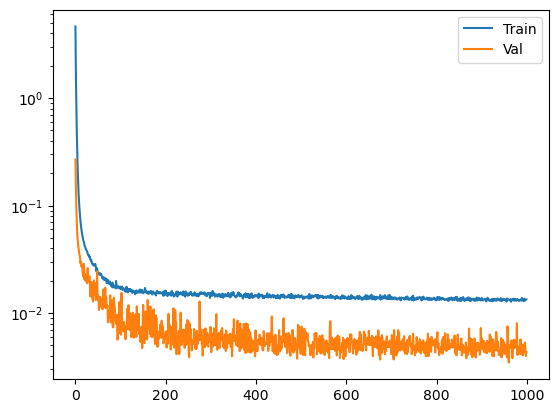

In [20]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.yscale('log')
plt.legend()